In [40]:
import numpy as np

input_data = np.load('initial_data/function_1/initial_inputs.npy')
print("Before:", input_data.shape)
new_point = np.array([
    [0.400690, 0.250449],
    [0.935709, 0.595154],
    ])
input_data = np.vstack([input_data, new_point])
print("After:", input_data.shape)
print(input_data)


Before: (10, 2)
After: (12, 2)
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.40069    0.250449  ]
 [0.935709   0.595154  ]]


In [41]:
output_data = np.load('initial_data/function_1/initial_outputs.npy')
print("Before:", output_data.shape)
new_output = np.array([
    1.3691278884153539e-21,
    2.0602633753627453e-67,
    ])
output_data = np.append(output_data, new_output)
print("After:", output_data.shape)
print(output_data)


Before: (10,)
After: (12,)
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.36912789e-021  2.06026338e-067]


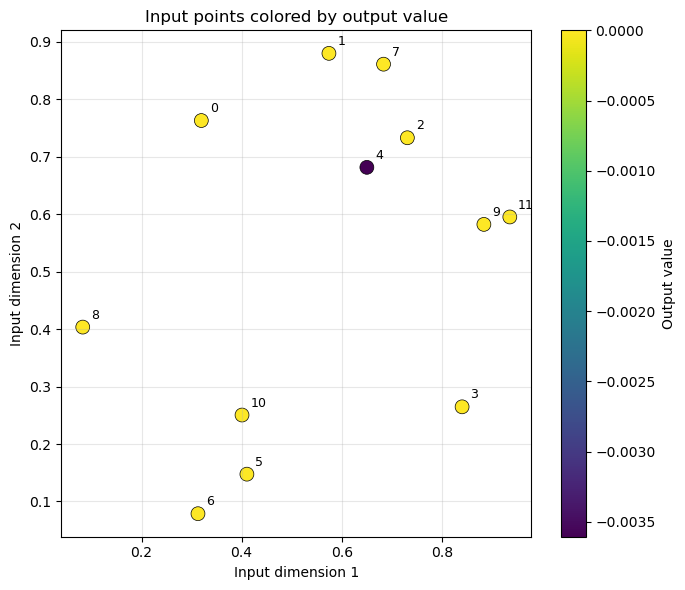

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
scatter = plt.scatter(input_data[:, 0], input_data[:, 1], 
                      c=output_data, cmap='viridis', 
                      s=100, edgecolors='black', linewidths=0.5)
plt.colorbar(scatter, label='Output value')

# Annotate each point with its index
for i, (x, y) in enumerate(input_data):
    plt.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.xlabel('Input dimension 1')
plt.ylabel('Input dimension 2')
plt.title('Input points colored by output value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

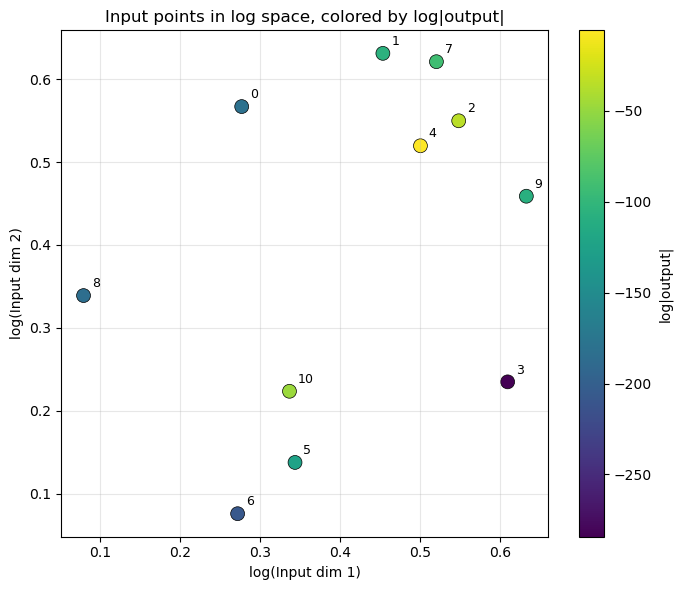

In [5]:
log_inputs = np.log1p(input_data)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(log_inputs[:, 0], log_inputs[:, 1], 
                      c=np.log(np.abs(output_data)), cmap='viridis', 
                      s=100, edgecolors='black', linewidths=0.5)
plt.colorbar(scatter, label='log|output|')

for i, (x, y) in enumerate(log_inputs):
    plt.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.xlabel('log(Input dim 1)')
plt.ylabel('log(Input dim 2)')
plt.title('Input points in log space, colored by log|output|')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [44]:
# Outputs span extreme ranges, so fit SVR in log|y| space
log_y = np.log(np.abs(output_data))

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(input_data)

print(f"log|y| range: [{log_y.min():.1f}, {log_y.max():.1f}]")
print(f"Negative outputs: {(output_data < 0).sum()} / {len(output_data)}")

log|y| range: [-284.3, -5.6]
Negative outputs: 3 / 12


In [45]:
svr = SVR(kernel='rbf', C=100.0, epsilon=0.5, gamma='scale')
svr.fit(X_scaled, log_y)

log_y_pred = svr.predict(X_scaled)
print(f"In-sample MSE (log space): {mean_squared_error(log_y, log_y_pred):.4f}")
print(f"In-sample R²  (log space): {r2_score(log_y, log_y_pred):.4f}")


In-sample MSE (log space): 1383.8614
In-sample R²  (log space): 0.7630


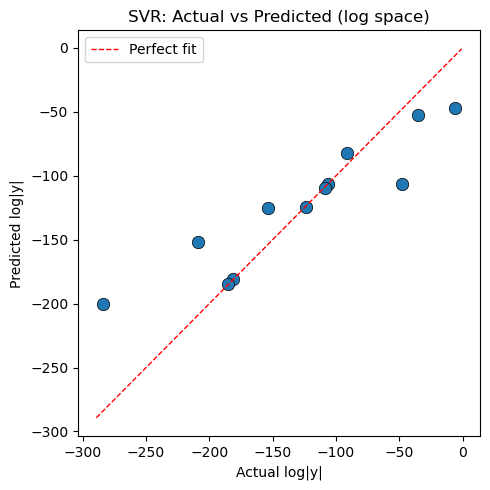

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(log_y, log_y_pred, edgecolors='black', linewidths=0.5, s=80)
lims = [log_y.min() - 5, log_y.max() + 5]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
plt.xlabel('Actual log|y|')
plt.ylabel('Predicted log|y|')
plt.title('SVR: Actual vs Predicted (log space)')
plt.legend()
plt.tight_layout()
plt.show()

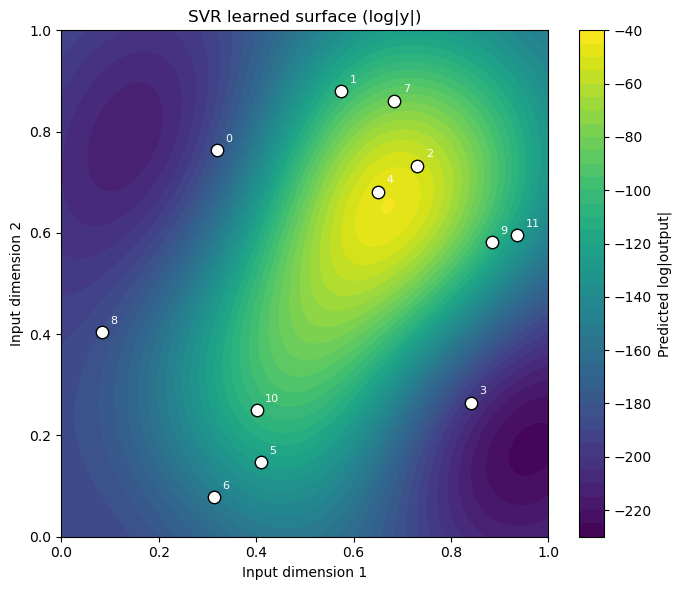

In [47]:
grid_res = 200
xx, yy = np.meshgrid(np.linspace(0, 1, grid_res),
                     np.linspace(0, 1, grid_res))
grid_scaled = scaler_X.transform(np.c_[xx.ravel(), yy.ravel()])
log_y_grid = svr.predict(grid_scaled).reshape(grid_res, grid_res)

plt.figure(figsize=(7, 6))
cf = plt.contourf(xx, yy, log_y_grid, levels=40, cmap='viridis')
plt.colorbar(cf, label='Predicted log|output|')
plt.scatter(input_data[:, 0], input_data[:, 1],
            c='white', edgecolors='black', s=80, zorder=5)
for i, (x, y) in enumerate(input_data):
    plt.annotate(str(i), (x, y), textcoords='offset points',
                 xytext=(6, 6), fontsize=8, color='white')
plt.xlabel('Input dimension 1')
plt.ylabel('Input dimension 2')
plt.title('SVR learned surface (log|y|)')
plt.tight_layout()
plt.show()

In [49]:
query = np.array([[0.5, 0.5]])
log_pred = svr.predict(scaler_X.transform(query))[0]

actual_output = 2.6752879910742468e-9
actual_log    = np.log(np.abs(actual_output))

pred_output   = np.exp(log_pred)
abs_error     = np.abs(pred_output - actual_output)
rel_error     = abs_error / np.abs(actual_output) * 100

print(f"Query point:           {query[0]}")
print(f"Predicted log|output|: {log_pred:.4f}")
print(f"Actual    log|output|: {actual_log:.4f}")
print(f"Predicted |output|:    {pred_output:.4e}")
print(f"Actual    |output|:    {actual_output:.4e}")
print(f"Absolute error:        {abs_error:.4e}")
print(f"Relative error:        {rel_error:.2f}%")    

Query point:           [0.5 0.5]
Predicted log|output|: -72.6098
Actual    log|output|: -19.7392
Predicted |output|:    2.9240e-32
Actual    |output|:    2.6753e-09
Absolute error:        2.6753e-09
Relative error:        100.00%
